In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid, cumulative_trapezoid
from scipy.interpolate import interp1d, CubicSpline
from scipy.stats import norm, lognorm

# Cinética de Procesos (Sesión 05)

<img src="figures/LogoCinvestav.png" style="height:100px" title="Cinvestav">

**CINVESTAV Unidad Saltillo**

**Programa de Maestría en Ciencias en Ingeniería Metalúrgica**

Dr. Edgar Ivan Castro Cedeño

Contacto:
[edgar.castro@cinvestav.mx](mailto:edgar.castro@cinvestav.mx)

# 2. Características de las curvas RTD

## 2.1 Relación entre $E(t)$ y $F(t)$

$E(t)$ es la distribución de tiempos de residencia, y $F(t)$ es la distribución acumulada de tiempos de residencia. La relación entre las mismas está dada por:

$$E(t) = \frac{dF(t)}{dt}$$

$$\int_{0}^{\infty} E(t) dt = 1$$

- La fracción del efluente que ha estado en el reactor durante un tiempo más pequeño que $t$ se puede calcular como:

$$\int_{0}^{t} E(t) dt = F(t)$$

- De forma análoga, la fracción de efluente que ha estado en el reactor por un tiempo más grande que $t$ se calcula como:

$$\int_{t}^{\infty} E(t) dt = 1 - F(t)$$

## 2.2 Momentos de la distribución

La comparativa entre distintas RTD se puede hacer de forma directa, o utilizando los momentos de las distribuciones. Para el segundo caso, normalmente se utilizan los tres primeros momentos:

- Tiempo de residencia promedio.
- Varianza.
- Asimetría.

### 2.2.1 Tiempo de residencia promedio

El tiempo de residencia promedio se puede calcular a partir de una curva RTD, como el primer momento de la función $E(t)$. Entonces el cálculo del tiempo de residencia promedio es:

$$t_m = \frac{\displaystyle \int_{0}^{\infty} t E(t) dt}{\displaystyle \int_{0}^{\infty} E(t) dt} = \int_{0}^{\infty} t E(t) dt$$

En el estudio de reactores ideales se definió el tiempo espacial como el tiempo requerido para tratar un volumen de reactor:

$$\tau = \frac{V}{\dot{Q}}$$

En reactores (ideales o no ideales) con condiciones de flujo volumétrico constante, y en los que no exista dispersión, el tiempo de residencia promedio será igual al tiempo espacial del reactor.

$$t_{m} = \tau$$

### 2.2.2 Varianza

La varianza mide la dispersión de los tiempos de residencia con respecto al tiempo de residencia promedio:

$$\sigma^2 = \int_{0}^{\infty} \left(t-t_m\right)^2 E(t) dt$$

Entre más grande sea, mas grande será la dispersión. Matemáticamente la varianza corresponde al cuadrado de la desviación estándar.

### 2.2.3 Asimetría estadística

La asimetría estadística mide el grado de simetría de la distribución con respecto al tiempo de residencia promedio:

$$s^3 = \frac{1}{\displaystyle {\sigma^{2}}^3} \int_{0}^{\infty} \left(t - t_m\right)^3 E(t) dt$$

## 2.3 Ejemplos

### 2.3.1 Ejemplo

    Fogler, Ex. 16.2

Utilizando los datos proporcionados debajo:

- Construya las curvas $E(t)$ y $F(t)$.
- Calcule el tiempo de residencia promedio, $t_m$ y la varianza, $\sigma^2$.
- Calcule la fracción de fluido que:
    - pasa entre 3 y 6 minutos en el reactor.
    - pasa menos de dos minutos en el reactor.
    - pasa mas de tres minutos en el reactor.

In [17]:
t = np.array([0, 0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14]) # min
C = np.array([0, 0.6, 1.4, 5, 8, 10, 8, 6, 4, 3, 2.2, 1.5, 0.6, 0]) # g/m3

**Interpolación e integración:**

In [18]:
# Curva C(t)
Ci = interp1d(t, C, kind='linear') # linear
Cs = CubicSpline(t, C) # spline
# Curva E(t)
Ei = interp1d(t, Ci(t)/trapezoid(Ci(t),t)) # linear
Es = CubicSpline(t, Cs(t)/Cs.integrate(t[0], t[-1])) # spline
# Curva F(t)
Fi = interp1d(t, cumulative_trapezoid(Ei(t), t, initial=0)) # linear
Fs = Es.antiderivative() # spline

print(10*' ', "Linear   Splines")
print(f"∫ E(t)dt = {trapezoid(Ei(t),t):.4f} | {Es.integrate(t[0], t[-1]):.4f}")

           Linear   Splines
∫ E(t)dt = 1.0000 | 1.0000


**Cálculo de momentos:**

In [19]:
# Moments (linear interpolation)
tmi = trapezoid(t*Ei(t), t) # mean residence time
s2i = trapezoid((t-tmi)**2 * Ei(t), t) # variance
s3i = trapezoid(1/(s2i**3)*(t-tmi)**3 * Ei(t), t) # skewness

# Moments (spline interpolation)
tms = CubicSpline(t, t*Es(t)).integrate(t[0], t[-1])  # mean residence time
s2s = CubicSpline(t, (t-tms)**2 * Es(t)).integrate(t[0], t[-1]) # variance
s3s = CubicSpline(t, 1/(s2s**3)*(t-tms)**3 * Es(t)).integrate(t[0], t[-1]) # skewness


print(14*' ', "Linear     Splines")
print(f"tm   [min]: {tmi:8.2f} | {tms:8.2f}")
print(f"σ    [min]: {np.sqrt(s2i):8.2f} | {np.sqrt(s2s):8.2f}")
print(f"σ2 [min^2]: {s2i:8.2f} | {s2s:8.2f}")
print(f"s3 [min^3]: {s3i:8.2f} | {s3s:8.2f}")

               Linear     Splines
tm   [min]:     5.10 |     5.09
σ    [min]:     2.46 |     2.49
σ2 [min^2]:     6.05 |     6.22
s3 [min^3]:     0.05 |     0.05


**Comparación:**

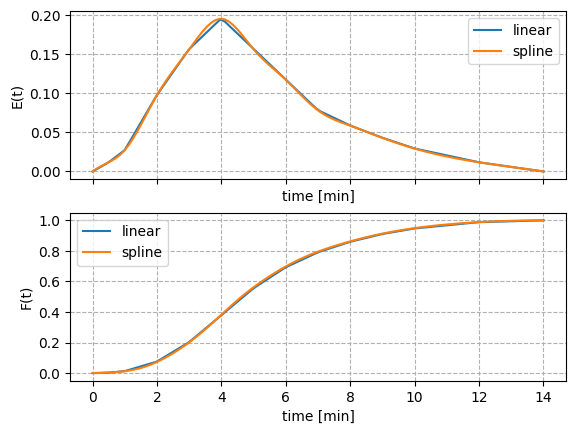

In [20]:
ti = np.linspace(0, 14, 100)
fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True)
ax0.plot(ti, Ei(ti), label='linear')
ax0.plot(ti, Es(ti), label='spline')
ax1.plot(ti, Fi(ti), label='linear')
ax1.plot(ti, Fs(ti), label='spline')
ax0.set_ylabel("E(t)")
ax1.set_ylabel("F(t)")
for ax in (ax0, ax1):
    ax.set_xlabel("time [min]")
    ax.legend()
    ax.grid(ls='--')
plt.show()

In [21]:
# calculo de fracciones de fluido
los, his = (3, min(t), 3), (6, 2, max(t))
print(45*' ', "Linear  Splines")
for lo, hi in zip(los, his):
    print(f"Fraction spent between {lo:4.1f} and {hi:4.1f} minutes: {Fi(hi)-Fi(lo):.4f} | {Fs(hi)-Fs(lo):.4f}")

                                              Linear  Splines
Fraction spent between  3.0 and  6.0 minutes: 0.4902 | 0.4968
Fraction spent between  0.0 and  2.0 minutes: 0.0755 | 0.0730
Fraction spent between  3.0 and 14.0 minutes: 0.7971 | 0.7986


### 2.3.2 Ejemplo

    Levenspiel, Ex. 11.1

In [22]:
t = np.array([0, 5, 10, 15, 20, 25, 30, 35]) # min
C = np.array([0, 3, 5, 5, 4, 2, 1, 0]) # g/dm3

**Interpolación e integración:**

In [23]:
# Curva C(t)
Ci = interp1d(t, C, kind='linear') # linear
Cs = CubicSpline(t, C) # spline
# Curva E(t)
Ei = interp1d(t, Ci(t)/trapezoid(Ci(t),t)) # linear
Es = CubicSpline(t, Cs(t)/Cs.integrate(t[0], t[-1])) # spline
# Curva F(t)
Fi = interp1d(t, cumulative_trapezoid(Ei(t), t, initial=0)) # linear
Fs = Es.antiderivative() # spline

print(10*' ', "Linear   Splines")
print(f"∫ E(t)dt = {trapezoid(Ei(t),t):.4f} | {Es.integrate(t[0], t[-1]):.4f}")

           Linear   Splines
∫ E(t)dt = 1.0000 | 1.0000


**Cálculo de momentos:**

In [24]:
# Moments (linear interpolation)
tmi = trapezoid(t*Ei(t), t) # mean residence time
s2i = trapezoid((t-tmi)**2 * Ei(t), t) # variance
s3i = trapezoid(1/(s2i**3)*(t-tmi)**3 * Ei(t), t) # skewness

# Moments (spline interpolation)
tms = CubicSpline(t, t*Es(t)).integrate(t[0], t[-1])  # mean residence time
s2s = CubicSpline(t, (t-tms)**2 * Es(t)).integrate(t[0], t[-1]) # variance
s3s = CubicSpline(t, 1/(s2s**3)*(t-tms)**3 * Es(t)).integrate(t[0], t[-1]) # skewness


print(14*' ', "Linear     Splines")
print(f"tm   [min]: {tmi:8.2f} | {tms:8.2f}")
print(f"σ    [min]: {np.sqrt(s2i):8.2f} | {np.sqrt(s2s):8.2f}")
print(f"σ2 [min^2]: {s2i:8.2f} | {s2s:8.2f}")
print(f"s3 [min^3]: {s3i:8.2f} | {s3s:8.2f}")

               Linear     Splines
tm   [min]:    15.00 |    14.89
σ    [min]:     6.89 |     7.16
σ2 [min^2]:    47.50 |    51.32
s3 [min^3]:     0.00 |     0.00


**Comparación:**

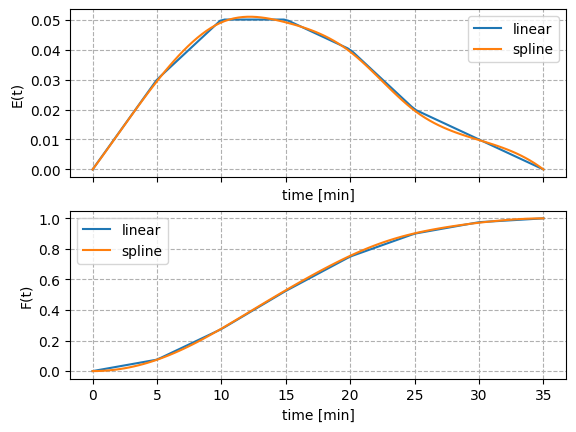

In [25]:
ti = np.linspace(0, 35, 100)
fig, (ax0, ax1) = plt.subplots(nrows=2, sharex=True)
ax0.plot(ti, Ei(ti), label='linear')
ax0.plot(ti, Es(ti), label='spline')
ax1.plot(ti, Fi(ti), label='linear')
ax1.plot(ti, Fs(ti), label='spline')
ax0.set_ylabel("E(t)")
ax1.set_ylabel("F(t)")
for ax in (ax0, ax1):
    ax.set_xlabel("time [min]")
    ax.legend()
    ax.grid(ls='--')
plt.show()

## 2.4 Función RTD Normalizada, $E(\Theta)$

Es frecuente utilizar una función RTD normalizada, $E(\Theta)$, en lugar de la función RTD, $E(t)$.

$$\Theta = \frac{\displaystyle t}{\displaystyle \tau}$$

$$E(\Theta) \equiv \tau E(t)$$


<details>
<summary><b>Nomenclatura</b></summary>

<div class="alert alert-info">

- **$t$**: tiempo, $[\mathrm{s}]$.

- **$\tau = \frac{\displaystyle V}{\displaystyle \dot{Q}}$**: tiempo espacial, $[\mathrm{s}]$.

- **$\Theta = \frac{\displaystyle t}{\displaystyle \tau}$**: tiempo espacial normalizado, $[\mathrm{-}]$.

- **$V$**: Volumen del reactor, $[\mathrm{m^{3}}]$.

- **$\dot{Q}$**: Flujo volumétrico, $[\mathrm{m^3.s^{-1}}]$.


</div>

</details>


En una función RTD convencional, para un tiempo, $t$, el valor de $E(t)$ dependerá del tamaño del reactor y del flujo volumétrico.

En una función RTD normalizada, para un valor de $\Theta$, el valor de $E(\Theta)$ siempre será el mismo independientemente del tamaño del reactor y del flujo volumétrico. Esto es porque el resultado del proceso de normalización da una función adimensional.